In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os, sys

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

sys.path.append(os.path.join(os.getcwd(), '..'))
from config import TARGET, ALERT_THRESHOLD

In [72]:
best_model        = joblib.load('../models/best_model.pkl')
X_test_scaled     = joblib.load('../models/X_test.pkl')
y_test            = joblib.load('../models/y_test.pkl')
selected_features = joblib.load('../models/feature_names.pkl')

print("Model    :", type(best_model).__name__)
print("Test set :", X_test_scaled.shape)
print(f"Fraud in test : {y_test.sum()}  |  Legit: {(y_test==0).sum()}")

Model    : RandomForestClassifier
Test set : (1817, 15)
Fraud in test : 16  |  Legit: 1801


In [73]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions sample:", y_pred[:10])
print("Risk scores sample :", np.round(y_prob[:10], 3))

Predictions sample: [0 1 0 0 0 0 0 0 0 0]
Risk scores sample : [0.177 0.512 0.174 0.334 0.169 0.169 0.357 0.255 0.171 0.272]


In [74]:
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Legit", "Suspicious"]))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Legit       1.00      0.84      0.91      1801
  Suspicious       0.04      0.69      0.07        16

    accuracy                           0.84      1817
   macro avg       0.52      0.76      0.49      1817
weighted avg       0.99      0.84      0.91      1817



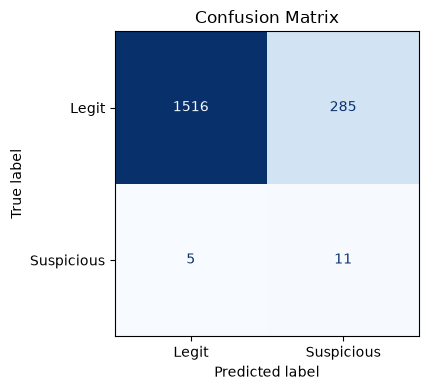


True  Negatives  (Legit correctly flagged legit) : 1516
False Positives  (Legit wrongly flagged fraud)   : 285
False Negatives  (Fraud missed by model)         : 5
True  Positives  (Fraud correctly caught)        : 11


In [75]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Legit", "Suspicious"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives  (Legit correctly flagged legit) : {tn}")
print(f"False Positives  (Legit wrongly flagged fraud)   : {fp}")
print(f"False Negatives  (Fraud missed by model)         : {fn}")
print(f"True  Positives  (Fraud correctly caught)        : {tp}")

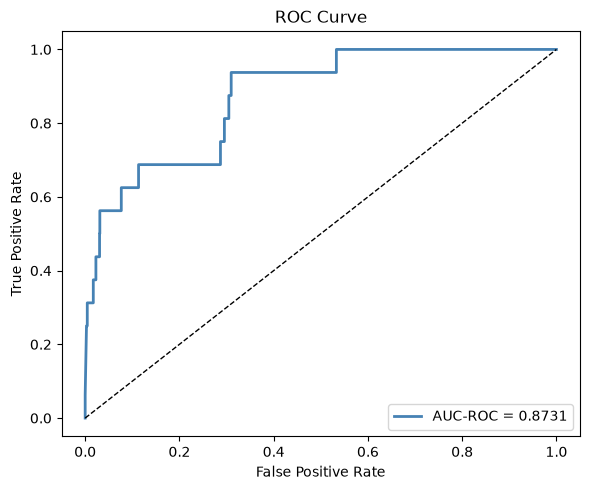

In [76]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_roc     = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f"AUC-ROC = {auc_roc:.4f}")
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/roc_curve.png")
plt.show()

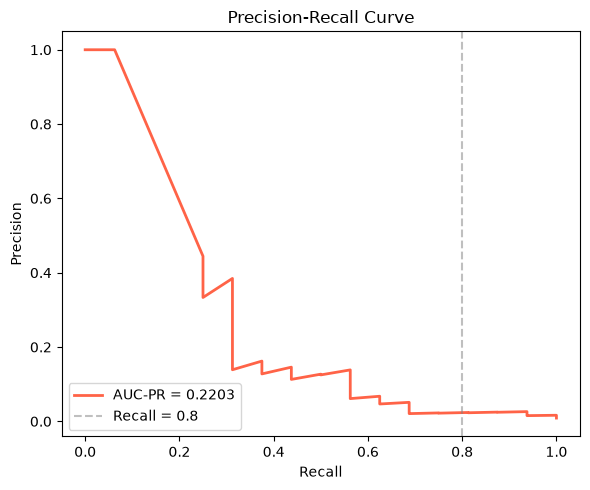

In [77]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
auc_pr = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='tomato', lw=2, label=f"AUC-PR = {auc_pr:.4f}")
plt.axvline(x=0.8, color='gray', linestyle='--', alpha=0.5, label="Recall = 0.8")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/pr_curve.png")
plt.show()

Best threshold : 0.80
Best F1 score  : 0.3125


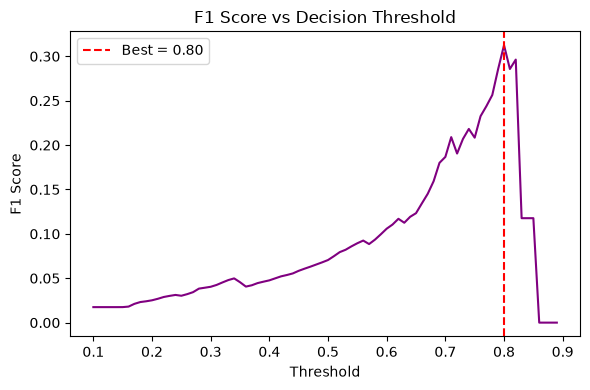

In [78]:
f1_scores = []
thresh_range = np.arange(0.1, 0.9, 0.01)

for t in thresh_range:
    preds = (y_prob >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    f1_scores.append(f1)

best_thresh = thresh_range[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

print(f"Best threshold : {best_thresh:.2f}")
print(f"Best F1 score  : {best_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(thresh_range, f1_scores, color='purple')
plt.axvline(x=best_thresh, color='red', linestyle='--', label=f"Best = {best_thresh:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Decision Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/threshold_f1.png")
plt.show()

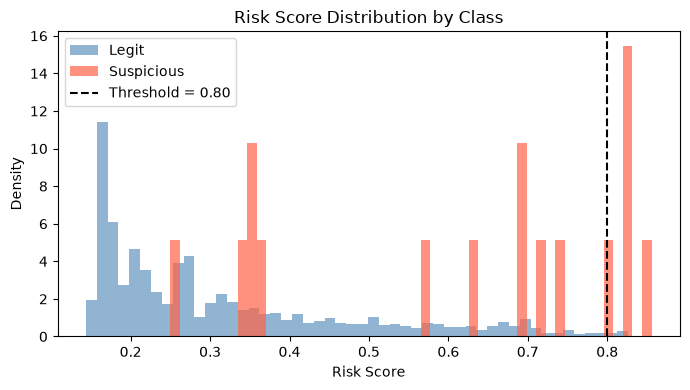

In [79]:
plt.figure(figsize=(7, 4))
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6,
         color='steelblue', label='Legit',      density=True)
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.7,
         color='tomato',     label='Suspicious', density=True)
plt.axvline(x=best_thresh, color='black', linestyle='--',
            label=f"Threshold = {best_thresh:.2f}")
plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.title("Risk Score Distribution by Class")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/risk_score_dist.png")
plt.show()

In [80]:
metrics = {
    "AUC_ROC"        : round(float(auc_roc),  4),
    "AUC_PR"         : round(float(auc_pr),   4),
    "Best_Threshold" : round(float(best_thresh), 2),
    "Best_F1"        : round(float(best_f1),  4),
    "True_Positives" : int(tp),
    "False_Positives": int(fp),
    "False_Negatives": int(fn),
    "True_Negatives" : int(tn)
}

os.makedirs("../reports", exist_ok=True)
with open("../reports/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved to reports/metrics.json")
print(json.dumps(metrics, indent=2))

Metrics saved to reports/metrics.json
{
  "AUC_ROC": 0.8731,
  "AUC_PR": 0.2203,
  "Best_Threshold": 0.8,
  "Best_F1": 0.3125,
  "True_Positives": 0,
  "False_Positives": 0,
  "False_Negatives": 16,
  "True_Negatives": 1516
}
